# Shared raw-space ROI panel for 1050 data

This notebook renders one shared raw-space field of view for ROIs 1382, 1379, and 1607.
The FoV is centered on the day-0 average centroid of the selected ROIs, red and green
channels stay separate, and the three ROI contours are overlaid in distinct colors.

Edit the values in the configuration cell to change the ROI set, z-window, or crop padding.


In [1]:
from pathlib import Path

import pandas as pd
import tifffile
from IPython.display import Image, display

from analysis_paths import get_dataset_analysis_dir, get_shape_qc_analysis_dir, resolve_dataset_dir
from roi_log_ratio_analysis import build_inverse_warped_mask_lookup, build_raw_image_lookup
from run_registered_roi_pipeline import infer_start_date_from_dataset_dir
from shared_raw_space_group_panel import render_shared_raw_space_group_panel


In [2]:
# Configuration for the shared FoV figure.
dataset_dir = resolve_dataset_dir("1050")
analysis_dir = get_dataset_analysis_dir("1050")
shape_qc_dir = get_shape_qc_analysis_dir("1050")
start_date = infer_start_date_from_dataset_dir(dataset_dir)

day0_mask_name = "mean_image_merge_cp_masks_SAM.tif"
inverse_mask_suffix = "_ROI_mask_SyN_inversed.tif"
preferred_channel = "red"

roi_ids = [1382, 1379, 1607]
center_day = 0
half_window_z = 3  # set to 5 if you want the wider z context later
crop_pad_xy = 20
min_crop_size_px = 48

summary_path = shape_qc_dir / "roi_log_ratio_summary_size_and_shape_filtered.csv"
metrics_path = shape_qc_dir / "roi_log_ratio_metrics_size_and_shape_filtered.csv"
output_dir = analysis_dir / f"shared_raw_space_group_panel_1050_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"dataset_dir={dataset_dir}")
print(f"shape_qc_dir={shape_qc_dir}")
print(f"output_dir={output_dir}")
print(f"start_date={start_date}")
print(f"roi_ids={roi_ids}")


dataset_dir=/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data
shape_qc_dir=/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data/analysis/roi_log_ratio_outputs_dark_median_corrected_meanMergeCPSAM_ROIs/shape_qc_filter
output_dir=/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data/analysis/shared_raw_space_group_panel_1050_20260624_165020
start_date=20260511
roi_ids=[1382, 1379, 1607]


In [3]:
# Load the filtered ROI tables and confirm the selected ROIs survived the regular QC steps.
roi_summary = pd.read_csv(summary_path).set_index("roi_id")
roi_metrics = pd.read_csv(metrics_path)

missing_from_summary = sorted(set(roi_ids).difference(roi_summary.index.astype(int).tolist()))
missing_from_metrics = sorted(set(roi_ids).difference(set(roi_metrics["roi_id"].astype(int).unique())))
if missing_from_summary:
    raise ValueError(f"Selected ROIs missing from summary table: {missing_from_summary}")
if missing_from_metrics:
    raise ValueError(f"Selected ROIs missing from metrics table: {missing_from_metrics}")

roi_summary.loc[roi_ids]


,n_days,day0_red,day0_green,day0_brightness,day0_log2_green_over_red,red_cv,green_cv,brightness_cv,min_delta_log2_green_over_red,day_of_min_delta,...,shape_qc_max_axis_ratio_x,proj_perimeter_px_y,circularity_y,solidity_y,eccentricity_y,axis_ratio_y,shape_qc_pass_y,shape_qc_min_circularity_y,shape_qc_min_solidity_y,shape_qc_max_axis_ratio_y
roi_id,,,,,,,,,,,,,,,,,,,,,
1382,5,4759.501139,630.762339,5390.263478,-2.913660,0.044563,0.279824,0.061094,-0.94981,4,...,2.0,56.367675,0.937342,0.955645,0.611957,1.264397,True,0.65,0.8,2.0
1379,5,3769.843456,768.126604,4537.970060,-2.293594,0.048589,0.189768,0.065582,-0.59763,4,...,2.0,55.582277,0.894870,0.948276,0.562742,1.209727,True,0.65,0.8,2.0
1607,5,2839.175889,494.862648,3334.038538,-2.517968,0.024936,0.085342,0.033281,0.00000,0,...,2.0,56.367675,0.885926,0.941176,0.766234,1.556272,True,0.65,0.8,2.0


In [4]:
# Load the raw image stacks and day-specific ROI masks once.
raw_lookup_paths = build_raw_image_lookup(dataset_dir, start_date=start_date)
mask_lookup_paths = build_inverse_warped_mask_lookup(
    image_dir=dataset_dir,
    day0_mask_name=day0_mask_name,
    inverse_mask_suffix=inverse_mask_suffix,
    preferred_channel=preferred_channel,
    start_date=start_date,
)

raw_stack_lookup = {
    (day, channel): tifffile.imread(path).astype(float)
    for (day, channel), path in sorted(raw_lookup_paths.items())
}
mask_stack_lookup = {day: tifffile.imread(path) for day, path in sorted(mask_lookup_paths.items())}

print(f"days={sorted(mask_stack_lookup)}")
print(f"raw_stacks={len(raw_stack_lookup)}")
print(f"mask_stacks={len(mask_stack_lookup)}")


days=[0, 1, 2, 3, 4]
raw_stacks=10
mask_stacks=5


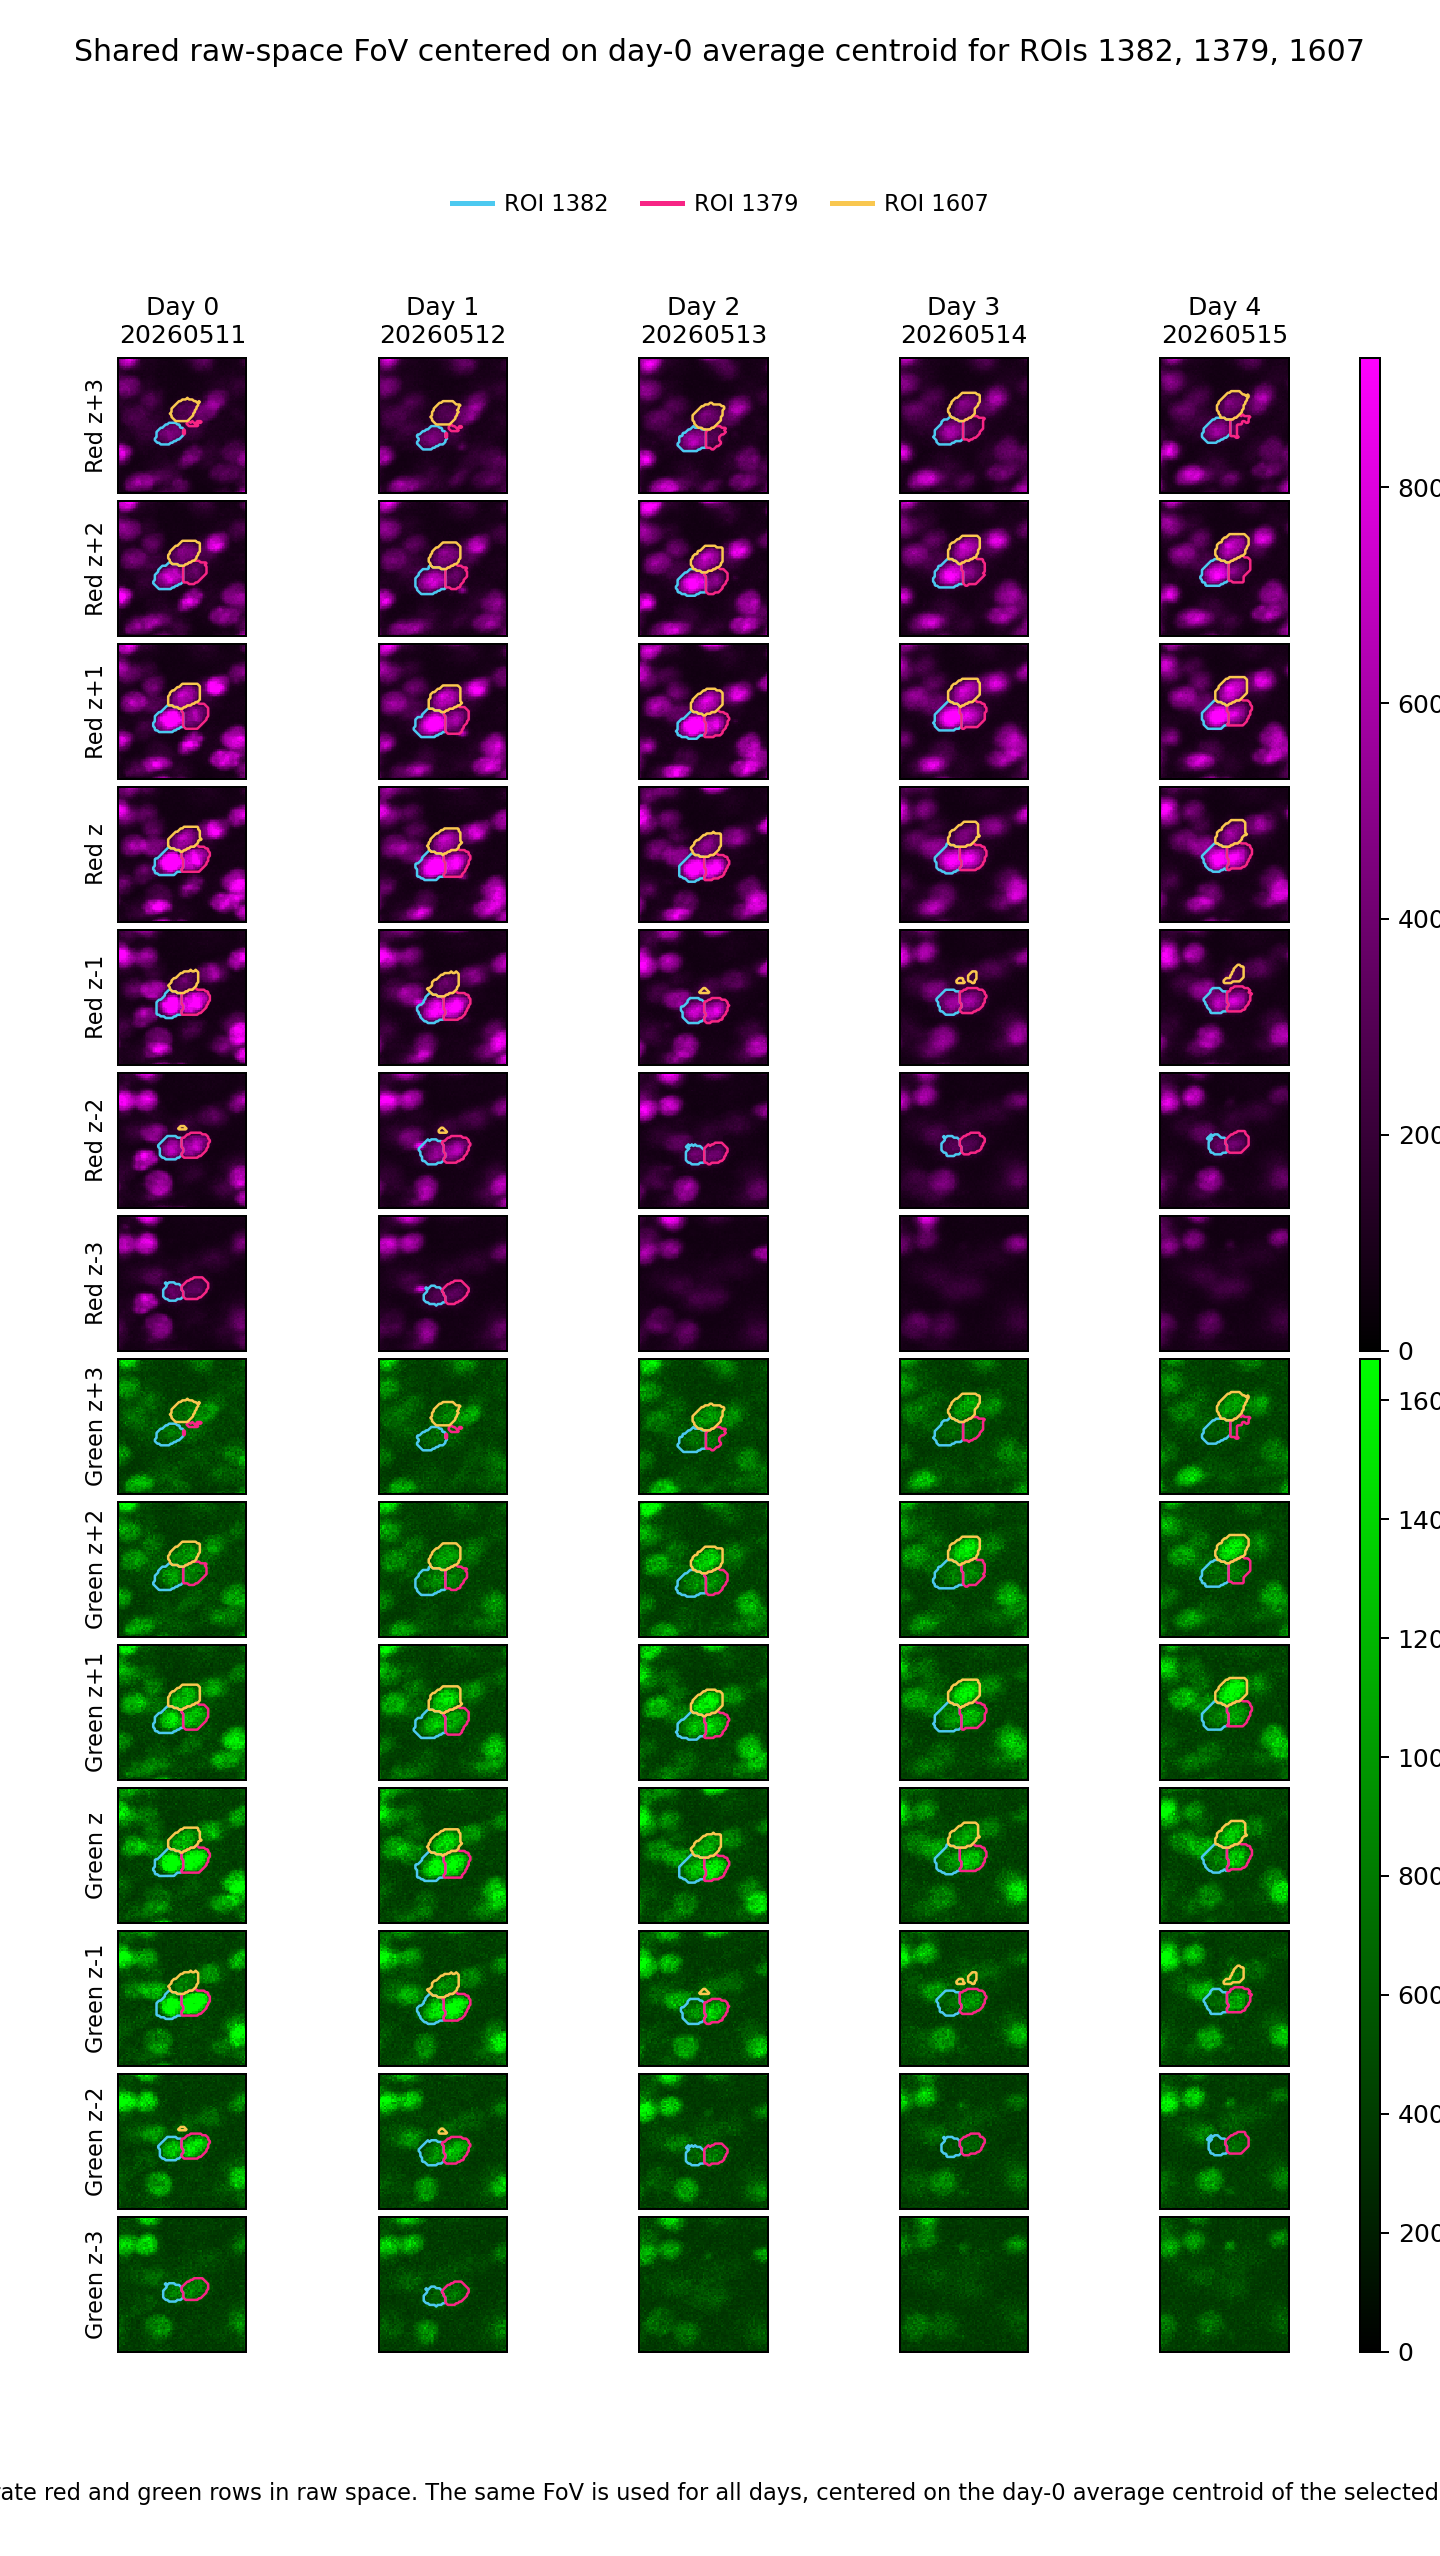

PosixPath('/mnt/d/_data/_newAAV_2026/Fucci-Tri_avg_images/1050_data/analysis/shared_raw_space_group_panel_1050_20260624_165020/shared_raw_space_group_panel_metadata.csv')

In [5]:
# Render the shared FoV panel and save the metadata table.
output_path = output_dir / "roi_1382_1379_1607_shared_raw_space_group_panel.png"
metadata_rows = render_shared_raw_space_group_panel(
    roi_ids=roi_ids,
    raw_stack_lookup=raw_stack_lookup,
    mask_stack_lookup=mask_stack_lookup,
    output_path=output_path,
    start_date=start_date,
    half_window_z=half_window_z,
    crop_pad_xy=crop_pad_xy,
    min_crop_size_px=min_crop_size_px,
    center_day=center_day,
)

metadata_path = output_dir / "shared_raw_space_group_panel_metadata.csv"
pd.DataFrame(metadata_rows).to_csv(metadata_path, index=False)
display(Image(filename=str(output_path)))
metadata_path
